Libraries loaded successfully.

Dataset Shape: (200, 10)
   Quiz_1  Midterm  Project  Quiz_2  Attendance  Final_Grade  Assignment_Avg  \
0    81.0     77.4     64.1    83.8        90.4         74.6            76.6   
1    73.3     80.4     74.0    62.0        77.4         69.6            72.4   
2    82.8     88.2     80.1    85.3        82.9         75.9            84.1   
3    93.3     87.8     80.5    91.6        77.8         75.5            88.3   
4    72.2     51.3     75.5    79.4        78.1         64.5            69.6   

   Trend Letter_Grade  At_Risk  
0   -5.3            C        0  
1   -8.8            D        1  
2   -2.8            C        0  
3   -4.5            C        0  
4   15.7            D        1  

Descriptive Statistics
           Quiz_1     Midterm     Project      Quiz_2  Attendance  \
count  200.000000  200.000000  200.000000  200.000000  200.000000   
mean    74.447000   72.983500   79.070000   73.972000   83.092000   
std     10.998835   14.055803    

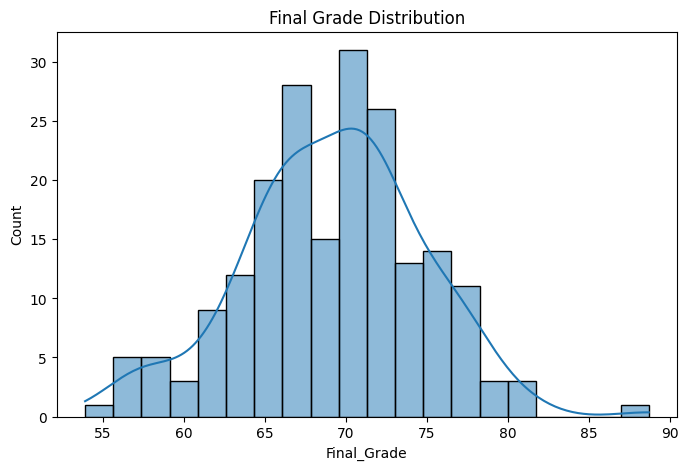

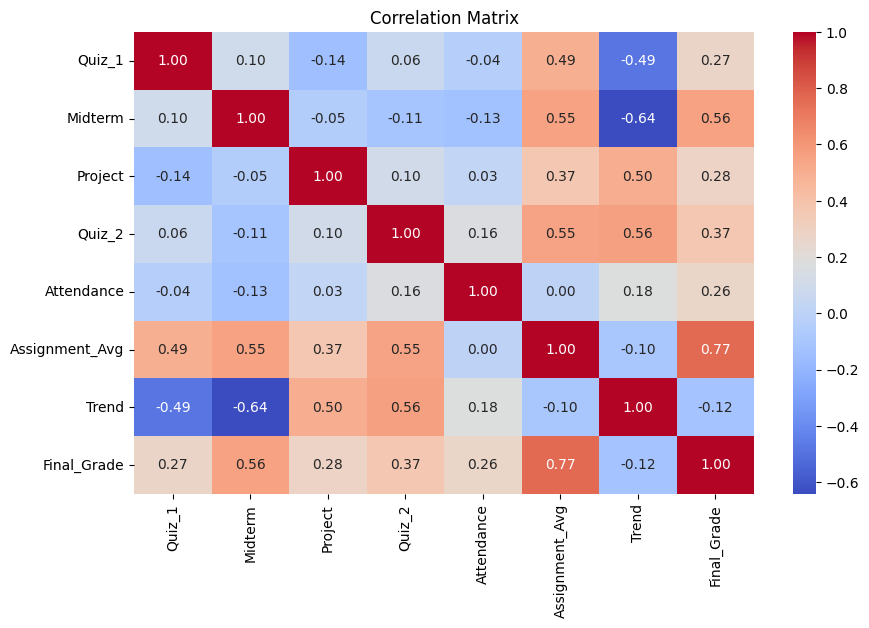


Linear Regression
Train R² : 0.7035
Test R²  : 0.6868
RMSE     : 2.9516
CV Score : 0.6752

Ridge Regression
Train R² : 0.7034
Test R²  : 0.6884
RMSE     : 2.9441
CV Score : 0.6809


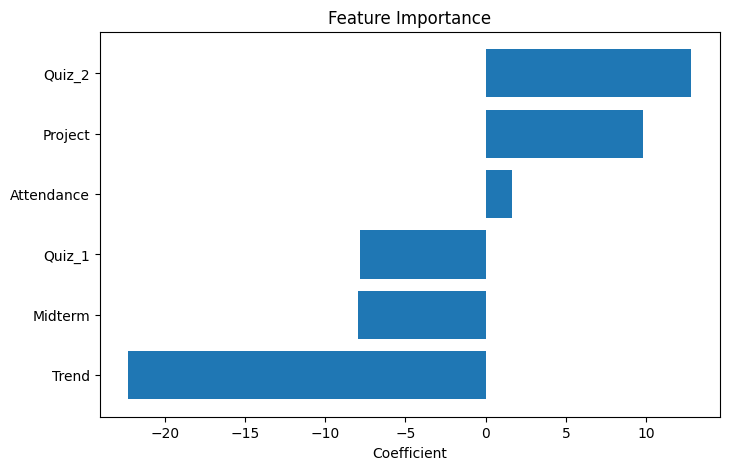

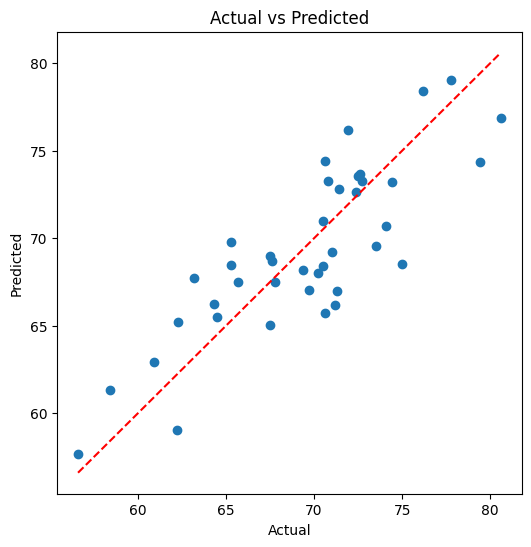


Student Prediction
----------------------
Predicted Grade : 74.24
Letter Grade    : C
Status          : On Track

Batch Prediction Results
    Name  Predicted_Grade Letter_Grade    Status
0  Alice             81.1            B  On Track
1    Raj             65.7            D   At Risk
2  Sofia             86.4            B  On Track
3  James             52.8            F   At Risk
4  Priya             73.3            C  On Track


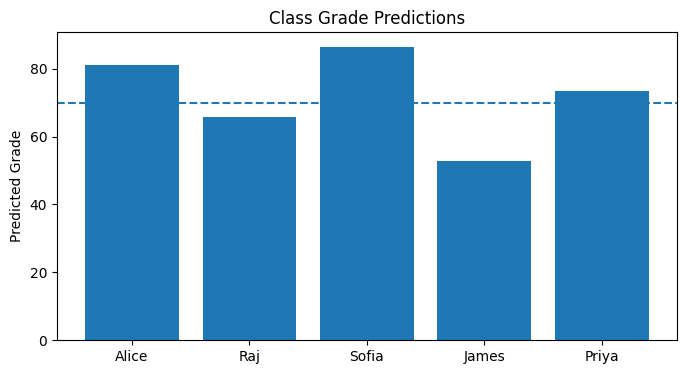


Project Completed Successfully.


In [2]:
# ============================================================
# STUDENT PERFORMANCE PREDICTION USING MACHINE LEARNING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

# ============================================================
# DATASET GENERATION
# ============================================================

np.random.seed(42)
n = 200

quiz1 = np.random.normal(75, 12, n).clip(0, 100)
midterm = np.random.normal(72, 15, n).clip(0, 100)
project = np.random.normal(80, 10, n).clip(0, 100)
quiz2 = np.random.normal(74, 13, n).clip(0, 100)
attendance = np.random.normal(82, 9, n).clip(0, 100)

final_grade = (
    0.15 * quiz1 +
    0.25 * midterm +
    0.20 * project +
    0.15 * quiz2 +
    0.15 * attendance +
    np.random.normal(0, 3, n)
).clip(0, 100)

df = pd.DataFrame({
    'Quiz_1': quiz1.round(1),
    'Midterm': midterm.round(1),
    'Project': project.round(1),
    'Quiz_2': quiz2.round(1),
    'Attendance': attendance.round(1),
    'Final_Grade': final_grade.round(1)
})

df['Assignment_Avg'] = df[['Quiz_1', 'Midterm', 'Project', 'Quiz_2']].mean(axis=1).round(1)

df['Trend'] = (
    df[['Quiz_2', 'Project']].mean(axis=1) -
    df[['Quiz_1', 'Midterm']].mean(axis=1)
).round(1)

def grade_letter(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['Letter_Grade'] = df['Final_Grade'].apply(grade_letter)
df['At_Risk'] = (df['Final_Grade'] < 70).astype(int)

print("\nDataset Shape:", df.shape)
print(df.head())

# ============================================================
# EDA
# ============================================================

print("\nDescriptive Statistics")
print(df.describe())

plt.figure(figsize=(8,5))
sns.histplot(df['Final_Grade'], bins=20, kde=True)
plt.title("Final Grade Distribution")
plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

num_cols = [
    'Quiz_1','Midterm','Project',
    'Quiz_2','Attendance',
    'Assignment_Avg','Trend','Final_Grade'
]

plt.figure(figsize=(10,6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# MODEL TRAINING
# ============================================================

FEATURES = [
    'Quiz_1',
    'Midterm',
    'Project',
    'Quiz_2',
    'Attendance',
    'Trend'
]

TARGET = 'Final_Grade'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate(model, name):
    train_pred = model.predict(X_train_sc)
    test_pred = model.predict(X_test_sc)

    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)

    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    cv = cross_val_score(
        model,
        X_train_sc,
        y_train,
        cv=5,
        scoring='r2'
    )

    print("\n" + "="*40)
    print(name)
    print("="*40)
    print("Train R² :", round(r2_train,4))
    print("Test R²  :", round(r2_test,4))
    print("RMSE     :", round(rmse,4))
    print("CV Score :", round(cv.mean(),4))

evaluate(lr, "Linear Regression")
evaluate(ridge, "Ridge Regression")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr.coef_
})

coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.show()

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

y_pred = lr.predict(X_test_sc)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# ============================================================
# SINGLE STUDENT PREDICTION
# ============================================================

def predict_student(
    quiz1,
    midterm,
    project,
    quiz2,
    attendance
):

    trend = (
        ((quiz2 + project)/2)
        -
        ((quiz1 + midterm)/2)
    )

    data = np.array([
        [
            quiz1,
            midterm,
            project,
            quiz2,
            attendance,
            trend
        ]
    ])

    data_scaled = scaler.transform(data)

    prediction = lr.predict(data_scaled)[0]

    prediction = max(0, min(100, prediction))

    print("\nStudent Prediction")
    print("----------------------")
    print("Predicted Grade :", round(prediction,2))
    print("Letter Grade    :", grade_letter(prediction))

    if prediction < 70:
        print("Status          : At Risk")
    else:
        print("Status          : On Track")

# Example Prediction
predict_student(
    quiz1=78,
    midterm=82,
    project=91,
    quiz2=74,
    attendance=85
)

# ============================================================
# BATCH PREDICTION
# ============================================================

roster = pd.DataFrame({
    'Name':['Alice','Raj','Sofia','James','Priya'],
    'Quiz_1':[88,72,95,55,80],
    'Midterm':[91,68,98,60,78],
    'Project':[85,75,92,50,82],
    'Quiz_2':[90,70,96,58,79],
    'Attendance':[95,80,98,65,88]
})

roster['Trend'] = (
    (roster['Quiz_2'] + roster['Project'])/2
    -
    (roster['Quiz_1'] + roster['Midterm'])/2
)

X_roster = scaler.transform(roster[FEATURES])

roster['Predicted_Grade'] = (
    lr.predict(X_roster)
).round(1)

roster['Letter_Grade'] = roster['Predicted_Grade'].apply(grade_letter)

roster['Status'] = roster['Predicted_Grade'].apply(
    lambda x: 'At Risk' if x < 70 else 'On Track'
)

print("\nBatch Prediction Results")
print(roster[['Name',
              'Predicted_Grade',
              'Letter_Grade',
              'Status']])

plt.figure(figsize=(8,4))
plt.bar(
    roster['Name'],
    roster['Predicted_Grade']
)
plt.axhline(70, linestyle='--')
plt.title("Class Grade Predictions")
plt.ylabel("Predicted Grade")
plt.show()

print("\nProject Completed Successfully.")